# Project 1:
# Simulation and estimation in a Markov model of breast cancer

In [52]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

## Part 2

In [53]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [54]:
### Given transition rate matrix
Q = np.array([
    [-0.0085,  0.0050,  0.0025,  0.0000,  0.0010],
    [ 0.0000, -0.01400, 0.0050,  0.0040,  0.0050],
    [ 0.0000,  0.0000, -0.0080,  0.0030,  0.0050],
    [ 0.0000,  0.0000,  0.0000,  -0.009,  0.0090],
    [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000]
])
print(Q)

### Possible states (0-indexed)
S = np.array([0,1,2,3,4])
print(S)

[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]
[0 1 2 3 4]


### Task 7

In [55]:
#Random seed
np.random.seed(43)

### Loop for bootstrap
N_BS_variables = 100
BS_mean_list = [] 
BS_stddev_list = []

#Number of observations wanted in each sample
N_obs = 1000

print("Beginning simulation...")
for i in range(N_BS_variables):
    if (i+1) % 10 == 0:
        print(f"Bootstrap loop {i+1}")
    

    #Initialise lifetimes
    lifetime_list_t7 = []
    #Initialise variables tracking number of simulated women
    women_all_count = 0
    #Initialise list for logging states history for women
    state_hist_list = []
    #Initialise list for logging times at which transitions happens
    time_hist_list = []
    #Initialise passed criterium counter
    crit_pass_count = 0

    ### Loop for each woman - until lifetimes for women meeting criteria have been simulated
    while women_all_count < N_obs:
        #Initialise state history for woman
        state = 0
        state_hist = [state]

        #Initialise time history for women
        lifetime = 0
        time_hist = [lifetime]

        #Pass crit variable (to not double count)
        crit_pass = False

        ### Time loop 
        #While women is not dead
        while state != 4:
            #Determine sojurn time rate from current state
            rate_soj = -Q[state, state]

            #Determine sojurn time stochastically (how long time women remains in state)
            t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)
    
            #Update lifetime 
            lifetime += t_soj

            #Extract transition probability (use copy due to how python lists work)
            prob_trans = Q[state,:].copy() / rate_soj
            prob_trans[state] = 0

            #Determine transition stochastically
            new_state = np.random.choice(a=S, p=prob_trans)

            #log new state and time in history
            state_hist.append(new_state)
            time_hist.append(lifetime)

            #Update state
            state = state_hist[-1]

            #Check criterium (women in state 2 or 3 after 30.5 months)
            if state in [2,3]:
                if lifetime > 30.5:
                    if crit_pass == False:
                        crit_pass_count += 1
                        crit_pass == True

        #log the lifetime, and log the state history for woman in history list 
        lifetime_list_t7.append(lifetime)
        state_hist_list.append(state_hist)
        time_hist_list.append(time_hist)

        #Increase woman counter
        women_all_count += 1 

  
    #Compute BS variables
    BS_mean = np.mean(lifetime_list_t7)
    BS_stddev = np.std(lifetime_list_t7, ddof=1)

    BS_mean_list.append(BS_mean)
    BS_stddev_list.append(BS_stddev)

print("Simulation done!")

Beginning simulation...
Bootstrap loop 10
Bootstrap loop 20
Bootstrap loop 30
Bootstrap loop 40
Bootstrap loop 50
Bootstrap loop 60
Bootstrap loop 70
Bootstrap loop 80
Bootstrap loop 90
Bootstrap loop 100
Simulation done!


In [56]:
BS_mean_est = np.mean(BS_mean_list)
BS_std_est = np.mean(BS_stddev_list)

CI_up_mean = np.percentile(BS_mean_list, q=2.5)
CI_lo_mean = np.percentile(BS_mean_list, q=97.5)

CI_up_std = np.percentile(BS_stddev_list, q=2.5)
CI_lo_std = np.percentile(BS_stddev_list, q=97.5)

print("mean and CIs")
print(BS_mean_est)
print(CI_up_mean, CI_lo_mean)

print("std and CIs")
print(BS_std_est)
print(CI_up_std, CI_lo_std)

mean and CIs
262.32613193328217
251.17762987075633 273.5522119542875
std and CIs
191.303294607682
179.14138267201642 204.4625693532886


In [57]:
1.86*12

22.32

In [58]:
### Check results
mean_sample_t7 = np.mean(lifetime_list_t7)
frac_t7 = crit_pass_count/women_all_count
print(f"Expected lifetime of women:\n{mean_sample_t7:.2f} months\n {mean_sample_t7/12:.2f} years")
print(f"Proportion of women where cancer reappears distantly after 30.5 months:\n{frac_t7:.3g}")


print("Length of lifetimes:", len(lifetime_list_t7))
print(f"Number of women simulated: {women_all_count}")

print("first vals of lifetimes:")
print(lifetime_list_t7[:10])
print("Example of state_hist:")
print(state_hist_list[1])
print("Example of time_hist:")
print(time_hist_list[1])

Expected lifetime of women:
268.10 months
 22.34 years
Proportion of women where cancer reappears distantly after 30.5 months:
0.839
Length of lifetimes: 1000
Number of women simulated: 1000
first vals of lifetimes:
[377.3605434046091, 188.570162002195, 367.6958706004717, 220.12356668390026, 451.8987609740642, 63.093815108351535, 235.17731961258045, 308.25317564418515, 228.62295866071779, 465.05287623992285]
Example of state_hist:
[0, 1, 3, 4]
Example of time_hist:
[0, 52.09225632070516, 54.96663955418828, 188.570162002195]


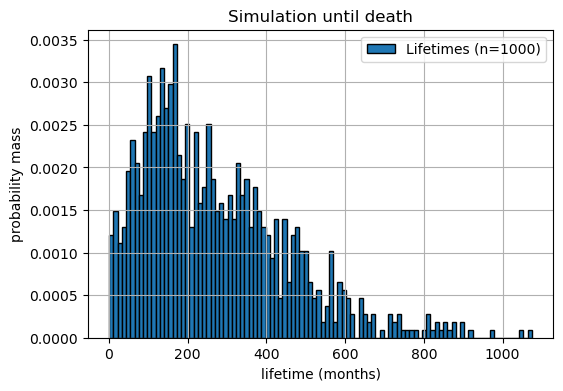

In [59]:
### Visualising
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(
    lifetime_list_t7, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death')
ax.legend()
ax.grid()

plt.show()

### Task 8

Compare the emperical lifetime distribution function, from your simulations,
to the theoretical, using an appropriate statistical test.

In [60]:
#Emperical distribution function
def F_n(x, obs):
    # number of observations
    n = np.size(obs)
    #Computing F_n by number of observations smaller that x for each x
    vals = np.zeros(np.size(x)) 
    for i in range(len(x)):
        vals[i] = (1/n) * np.sum(obs <= x[i])
    return vals

In [64]:
### Construct parameters for Continuous time phase-type distribution
#Submatrix of Q, minus last row and col
Q_s = Q[:-1,:-1].copy()
#Initial state, minus last element
p_0 = np.array([1,0,0,0])

def cdf_CTPT(t, p_0=p_0, Q_s=Q_s):
    d = np.shape(Q_s)[0]
    n = np.size(t)
    vals = np.zeros(n)
    for i in range(n):
        mat_exp = sp.linalg.expm(Q_s*t[i])
        mat_prod = p_0 @ mat_exp @ np.ones(d)
        vals[i] = 1 - mat_prod
    return vals

### Compute cdf vals
tgrid = np.linspace(0, 1200, num=4000)
#cdf_ctpt_vals = np.array([ cdf_CTPT(t) for t in tgrid])
cdf_ctpt_vals = cdf_CTPT(tgrid)
cdf_emp_vals = F_n(x=tgrid, obs=lifetime_list_t7)

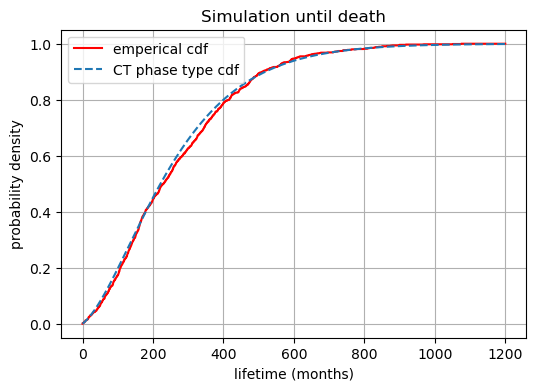

In [65]:
### Visualising with theoretical cdf
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    tgrid,
    cdf_emp_vals,
    label="emperical cdf",
    color='red'
)

ax.plot(
    tgrid,
    cdf_ctpt_vals,
    label="CT phase type cdf",
    linestyle='--'
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability density')
ax.set_title('Simulation until death')
ax.legend()
ax.grid()

plt.show()

In [66]:
### KS test af GOF test

print("Own computation")
# Computing KS test statistics (non-adjusted)
D_n = np.max(np.abs(cdf_emp_vals-cdf_ctpt_vals))
print(f"D_n: {D_n:.4g}")

# Computing adjusted test statistic
D_n_adj = (np.sqrt(N_obs) + 0.12 +  0.11/np.sqrt(N_obs))*D_n
print(f"adjusted D_n: {D_n_adj:.4g}")

# Computing the p-value form the cdf
cdf_val = sp.stats.kstwo.cdf(D_n, n=N_obs)
p_val = 1-cdf_val
print(f"p_val: {p_val:.4g}")

D_n_kstest, p_val_kstest = sp.stats.kstest(rvs=lifetime_list_t7, cdf=cdf_CTPT)
print("Using kstest from scipy.stats")
print(f"D_n_kstest: {D_n_kstest:.4g}")
print(f"p_val_kstest: {p_val_kstest:.4g}")


Own computation
D_n: 0.03707
adjusted D_n: 1.177
p_val: 0.1249
Using kstest from scipy.stats
D_n_kstest: 0.03743
p_val_kstest: 0.1183


### Part 9

A certain preventitive treatment results in the following transition-rate matrix instead:   
...   
Simulate 1000 women who have received this treatment. Plot the Kaplan-
Meier estimate of the survival function. In the same figure, plot the Kaplan-
Meier estimate of the survival function for women, who have not received
this treatment. Does the treatment appear to have an effect

In [67]:
### Compute missing diagonal values of new Q
row0 = np.array([0.0025, 0.00125, 0,     0.001]) 
row1 = np.array([0, 0, 0.002, 0.005])
row2 = np.array([0, 0, 0.003, 0.005])
row3 = np.array([0, 0, 0, 0.009])
row4 = np.array([0, 0, 0, 0])
rows = [row0, row1, row2, row3, row4]

for i in range(5):
    diagonal = -np.sum(rows[i])
    rows[i] = np.insert(rows[i], i, diagonal)

Qtreat = np.array(rows)
print("Q treatment:")
print(Qtreat)

Q treatment:
[[-0.00475  0.0025   0.00125  0.       0.001  ]
 [ 0.      -0.007    0.       0.002    0.005  ]
 [ 0.       0.      -0.008    0.003    0.005  ]
 [ 0.       0.       0.      -0.009    0.009  ]
 [ 0.       0.       0.       0.       0.     ]]


In [29]:
#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise list for logging lifetimes
lifetime_list_t9 = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise list for logging state histories for women
state_hist_list = []
#Initialise list for logging times at which transitions happens
time_hist_list = []
#Initialise passed criterium counter
crit_pass_count = 0

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
while women_all_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist = [state]

    #Initialise time history for women
    lifetime = 0
    time_hist = [lifetime]

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Determine sojurn time rate from current state
        rate_soj = -Qtreat[state, state]

        #Determine sojurn time stochastically (how long time women remains in state)
        t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)

        #Update lifetime 
        lifetime += t_soj

        #Extract transition probability (use copy due to how python lists work)
        prob_trans = Qtreat[state,:].copy() / rate_soj
        prob_trans[state] = 0

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #log new state and time in history
        state_hist.append(new_state)
        time_hist.append(lifetime)

        #Update state
        state = state_hist[-1]

    #log the lifetime, and log the state history for woman in history list 
    lifetime_list_t9.append(lifetime)
    state_hist_list.append(state_hist)
    time_hist_list.append(time_hist)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")

Beginning simulation...
Simulation done!


In [30]:
### Check results
mean_sample_t9 = np.mean(lifetime_list_t9)
print(f"Expected lifetime of women:\n{mean_sample_t9:.2f} months\n {mean_sample_t9/12:.2f} years")

print("Length of lifetimes:", len(lifetime_list_t9))
print(f"Number of women simulated: {women_all_count}")

print("first vals of lifetimes:")
print(lifetime_list_t9[:5])
print("Example of state_hist:")
print(state_hist_list[1])
print("Example of time_hist:")
print(time_hist_list[1])

Expected lifetime of women:
365.68 months
 30.47 years
Length of lifetimes: 1000
Number of women simulated: 1000
first vals of lifetimes:
[87.65246629389691, 234.60341713538537, 105.77772846316442, 407.31955117604394, 16.79172051481303]
Example of state_hist:
[0, 2, 4]
Example of time_hist:
[0, 230.92303612308476, 234.60341713538537]


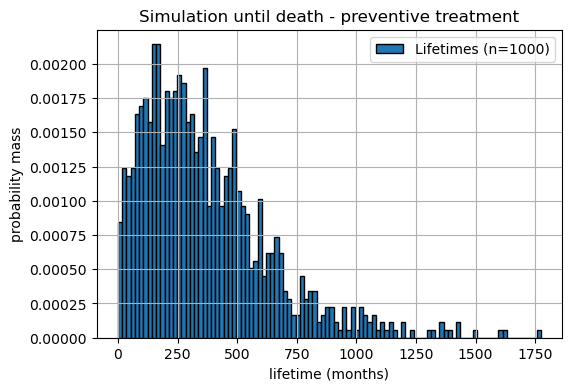

In [72]:
### Visualising
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(
    lifetime_list_t9, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death - preventive treatment')
ax.legend()
ax.grid()

plt.show()

In [74]:
### Kaplan-Meier estimator
def DiedWomen(t, obs):
    vals = np.zeros(np.size(t)) 
    for i in range(len(t)):
        vals[i] = np.sum(obs <= t[i])
    return vals

def KaplamMeierEstimator(t, obs, d=DiedWomen):
    N = len(obs)
    return (N-d(t=t, obs=obs))/N 

tgrid = np.linspace(0, 2000, num=2001)
KM_vals_t7 = KaplamMeierEstimator(t=tgrid, obs=lifetime_list_t7)
KM_vals_t9 = KaplamMeierEstimator(t=tgrid, obs=lifetime_list_t9)

print(np.shape(KM_vals_t9))


(2001,)


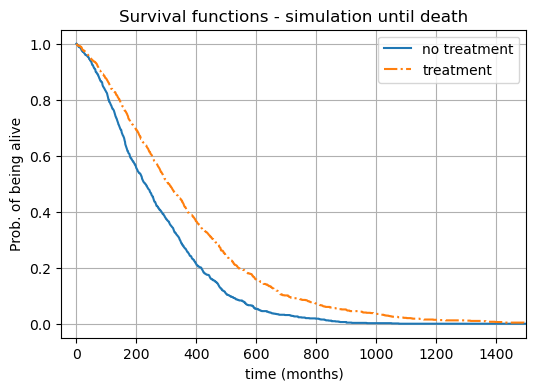

In [76]:
### Visualising the two survival functions
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    tgrid,
    KM_vals_t7,
    label="no treatment",
    )

ax.plot(
    tgrid,
    KM_vals_t9,
    label="treatment",
    linestyle='-.'
    )

ax.set_xlabel('time (months)')
ax.set_ylabel('Prob. of being alive')
ax.set_title('Survival functions - simulation until death')
ax.legend()
ax.grid()
ax.set_xlim(-50,1500)

plt.show()

### Task 10

In [34]:
### Performing logrank test
res1 = sp.stats.logrank(KM_vals_t7, KM_vals_t9)

print(res1)

LogRankResult(statistic=8.464717081503329, pvalue=2.5677523601076504e-17)


### Task 11

For the report, consider the following questions: What assumptions have
been eliminated, by going from the discrete to the continuous time model?
What have been added? How could the model be extended, such that the
sojourn times are Erlang distributed?

Assumptions removed:
1) discrete -> continuous: Women can not only transition state once per month (they  are 'checked' continiously)

Assumptions added:
1) Transition states are exponentially distributed

Extension/modification, such that sojourn times are Erlang distributed:   
A variable which is Erlang dist. with params $(k,\lambda)$ can be obtained by summing $k$ variables which are exponential distributed with rate paramter $\lambda$.   
So Sojourn times can  be Erlang distributed, if the variable is created by taking sum of previous variables exponential distributed variables. 


## Part 3

In [35]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [36]:
### Possible states (0-indexed)
S = np.array([0,1,2,3,4])
print("State vector")
print(S)    

State vector
[0 1 2 3 4]


In [37]:
### Compute missing diagonal values of new Q treatment
row0 = np.array([0.0025, 0.00125, 0,     0.001]) 
row1 = np.array([0, 0, 0.002, 0.005])
row2 = np.array([0, 0, 0.003, 0.005])
row3 = np.array([0, 0, 0, 0.009])
row4 = np.array([0, 0, 0, 0])
rows = [row0, row1, row2, row3, row4]

for i in range(len(rows)):
    diagonal = -np.sum(rows[i])
    rows[i] = np.insert(rows[i], i, diagonal)

Qtreat = np.array(rows)
print("Q treatment:")
print(Qtreat)

Q treatment:
[[-0.00475  0.0025   0.00125  0.       0.001  ]
 [ 0.      -0.007    0.       0.002    0.005  ]
 [ 0.       0.      -0.008    0.003    0.005  ]
 [ 0.       0.       0.      -0.009    0.009  ]
 [ 0.       0.       0.       0.       0.     ]]


### Task 12

Simulate 1000 women, starting in state 1, until death, using the same Q
as in the previous part. For each of the women, create a vector (or time
series) of her observed states Y(i). A time series will consist of the values
Y(i) = (X(0), X(48), X(96), . . . , ). The time series should continue until
death, thus the last value in each of the time series should be 5.

NB: Simulate, and then create time series vectors, which is each woman's state evaluated every 48 months

In [38]:
#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise list for logging lifetimes
lifetime_list_t12 = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise list for logging state histories for women
state_hist_list_t12 = []
#Initialise list for logging times at which transitions happens
time_hist_list_t12 = []

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
while women_all_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist = [state]

    #Initialise time history for women
    lifetime = 0
    time_hist = [lifetime]

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Determine sojurn time rate from current state
        rate_soj = -Qtreat[state, state]

        #Determine sojurn time stochastically (how long time women remains in state)
        t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)

        #Update lifetime 
        lifetime += t_soj

        #Extract transition probability 
        prob_trans = -Qtreat[state,:].copy() / Qtreat[state,state]
        prob_trans[state] = 0

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #log new state and time in history
        state_hist.append(new_state)
        time_hist.append(lifetime)

        #Update state
        state = state_hist[-1]

    #log the lifetime, and log the state history for woman in history list 
    lifetime_list_t12.append(lifetime)
    state_hist_list_t12.append(state_hist)
    time_hist_list_t12.append(time_hist)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")

Beginning simulation...
Simulation done!


In [39]:
### Check results
mean_sample_t12 = np.mean(lifetime_list_t12)
print(f"Expected lifetime of women:\n{mean_sample_t12:.2f} months\n {mean_sample_t12/12:.2f} years")

print("Length of lifetimes:", len(lifetime_list_t12))
print(f"Number of women simulated: {women_all_count}")

idx=0
print("first vals of lifetimes:")
print(lifetime_list_t12[:5])
print("Example of state_hist:")
print(state_hist_list_t12[idx])
print("Example of time_hist:")
print(time_hist_list_t12[idx])

Expected lifetime of women:
365.68 months
 30.47 years
Length of lifetimes: 1000
Number of women simulated: 1000
first vals of lifetimes:
[87.65246629389691, 234.60341713538537, 105.77772846316442, 407.31955117604394, 16.79172051481303]
Example of state_hist:
[0, 2, 3, 4]
Example of time_hist:
[0, 25.732482697405892, 43.62840057107899, 87.65246629389691]


In [40]:
#Function for creating time series
def coarse_time_series(time_hist, state_hist, step=48):
    time_hist = np.asarray(time_hist)
    state_hist = np.asarray(state_hist)

    # Create coarse grid up to the last time
    t_max = time_hist[-1]
    coarse_times = np.arange(0, t_max + step, step)

    # Find indices of active states
    idx = np.searchsorted(time_hist, coarse_times, side="right") - 1
    idx = np.clip(idx, 0, len(state_hist) - 1)

    ts_state = state_hist[idx]

    # Ensure last value is the final state (e.g., death = 4)
    ts_state[-1] = state_hist[-1]

    return ts_state, coarse_times

### Example
i = 1
lifetime_i = lifetime_list_t12[i]
time_hist_i = time_hist_list_t12[i]
state_hist_i = state_hist_list_t12[i]

print(f"Example of state_hist for woman {i}:")
print(state_hist_i)
print(f"Example of time_hist for woman {i}:")
print(time_hist_i)

ts_state, ts_time  = coarse_time_series(time_hist_i, state_hist_i)
print(f"coarse time grid for woman {i}")
print(ts_time)
print(f"time series of states for woman {i}")
print(ts_state)


Example of state_hist for woman 1:
[0, 2, 4]
Example of time_hist for woman 1:
[0, 230.92303612308476, 234.60341713538537]
coarse time grid for woman 1
[  0.  48.  96. 144. 192. 240.]
time series of states for woman 1
[0 0 0 0 0 4]


In [41]:
### Apply time_series maker
ts_states_list = []
ts_times_list = []

for i in range(N_obs):
    #Extract time and state history
    time_hist_i = time_hist_list_t12[i]
    state_hist_i = state_hist_list_t12[i]
    #Convert to coarse time series
    ts_state, ts_time  = coarse_time_series(time_hist_i, state_hist_i)
    #Append
    ts_states_list.append(ts_state)
    ts_times_list.append(ts_time)

i = 1
print("length of TS lists")
print(len(ts_states_list))
print("time series states:")
print(ts_states_list[i])
print("time series times:")
print(ts_times_list[i])

length of TS lists
1000
time series states:
[0 0 0 0 0 4]
time series times:
[  0.  48.  96. 144. 192. 240.]


### Task 13

For the remainder of this part, we will assume those 1000 time series is all
we have observed.   
It can be shown that an unbiased estimator of the transition rates, $q_{ij}$ , is

$$ q_{ij} = \frac{N_{ij}}{S_i} \quad \mathrm{for} \quad i \neq j $$

Where $N_{ij}$ is the total number of jumps (for all of the women) from state i
to j, and $S_i$ is the total sojourn time in state i (for all of the women). The
diagonal elements are found from equation (1). The problem is that $N_{ij}$ and
$S_i$ are unknown, all we know are the timeseries of observations every 4’th
year.
One approach to estimation is to recreate $N_{ij}$ and $S_i$ from the partial infor-
mation that we have observed

In [44]:
### Part 1 in algorithm
#Initialise Qk matrix
Qk = Q0.copy()
#Initialise Si, list for sojourn times in each state (for all states except death)
Si = np.zeros(len(S)-1)
#Initialise N_ij matrix, number of jumps from state i tom j
Nij = np.zeros([5,5])
#Initialise variables tracking number of simulated women
women_count = 1
### For OG woman i
#Extract time series: states and times 
states_OG= ts_states_list[women_count]
times_OG = ts_times_list[women_count]
print("Q0")
print(Q0)

print(f"for woman {women_count}")
print(states_OG)
print(times_OG)

Q0
[[-0.97183642  0.15599452  0.02058449  0.18340451  0.61185289]
 [ 0.         -1.41364596  0.96990985  0.30424224  0.13949386]
 [ 0.          0.         -0.81690108  0.52475643  0.29214465]
 [ 0.          0.          0.         -0.36636184  0.36636184]
 [ 0.          0.          0.          0.         -0.        ]]
for woman 1
[0 0 0 0 0 4]
[  0.  48.  96. 144. 192. 240.]


In [46]:
np.random.seed(42)

# Randomly inititate Q_est
Q_est = np.random.rand(5, 5) * 0.01
# Make diagonal elements obey relation
for i in range(5):
    Q_est[i, i] = -(Q_est[i,:].sum() - Q_est[i, i])

print(Q_est)
current_state = 0
print(np.sum(Q_est, axis=1))

p = Q_est[current_state].copy() / -Q_est[current_state,current_state]
p[current_state] = 0.0

print(p)
p = p / p.sum()

print(p)

[[-0.02437385  0.00950714  0.00731994  0.00598658  0.00156019]
 [ 0.00155995 -0.02331358  0.00866176  0.00601115  0.00708073]
 [ 0.00020584  0.0096991  -0.01384658  0.00212339  0.00181825]
 [ 0.00183405  0.00304242  0.00524756 -0.01303632  0.00291229]
 [ 0.00611853  0.00139494  0.00292145  0.00366362 -0.01409853]]
[-2.16840434e-19 -8.67361738e-19 -1.73472348e-18  4.33680869e-19
  0.00000000e+00]
[0.         0.39005498 0.30031933 0.24561503 0.06401066]
[0.         0.39005498 0.30031933 0.24561503 0.06401066]


In [47]:
### ALgorithm for estimating the q_ij's
### Renaming own data
observations = ts_states_list
interval = 48
death_state = 4

np.random.seed(43)

# Randomly inititate Q_est
Q_est = np.random.rand(5, 5) * 0.01
# Make diagonal elements obey relation
for i in range(5):
    Q_est[i, i] = -(Q_est[i,:].sum() - Q_est[i, i])

print("Initial guess on Q")
print(Q_est)

max_iter = 100
tol = 1e-4
diffs = []
best_diff = 1e5

# Iterating loop to find best Q
for iteration in range(max_iter):
    N = np.zeros((5, 5)) #jump count matrix
    S = np.zeros(5) #sojourn time vector

    #Looping through each OG observed woman (woman i)
    for obs in observations:
        #Looping through each observation interval for woman i
        for k in range(len(obs) - 1):
            start = obs[k]
            end   = obs[k + 1]

            #If death state is rached, add interval time (???) and go to next woman
            if start == death_state:
                S[death_state] += interval
                print("hello?")
                continue

            #State var. checking whether simulated women has trajectory corresponding to OG obs. woman 
            accepted = False
            #Restarting simulation until sim. woman's trajectory matches OG obs. woman's 
            while not accepted:
                current_state = start
                time = 0.0
                #The time at which a jump occurs 
                jump_times = []
                jump_states = []

                #Simulate for 48 months
                while time < interval and current_state != death_state:
                    #Stochastically draw time
                    rate = -Q_est[current_state, current_state]
                    state_time = np.random.exponential(1 / rate)

                    #Stop when simulated time exceeds 48 months
                    if time + state_time > interval:
                        break

                    #Update time
                    time += state_time
                    p = Q_est[current_state].copy() / -Q_est[current_state, current_state]
                    p[current_state] = 0.0
                    next_state = np.random.choice([0, 1, 2, 3, 4], p=p)

                    jump_times.append(time)
                    #States jumped into
                    jump_states.append(next_state)
                    current_state = next_state

                # Update state var. if sim. woman has reached state of OG obs. 
                # otherwise, sim. will be redone
                if current_state == end:
                    accepted = True

            prev_t = 0.0
            #Current state of woman 
            current = start

            #For all the states, the sim. woman entered doing the interval
            for t, s in zip(jump_times, jump_states):
                #sojourn time: difference between time for jump out of current state (t), and time at jump into state (prev_t)
                S[current] += t - prev_t
                N[current, s] += 1
                #move to next state into which sim. women jumped
                current = s
                prev_t = t

            #add time in last state, time not covered in above loop 
            S[current] += interval - prev_t

    #Computing new Q from estimator of each element
    Q_new = np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            if i != j and S[i] > 0:
                Q_new[i, j] = N[i, j] / S[i]
        Q_new[i, i] = -Q_new[i].sum()

    #Compute metric for convergence criterion
    diff = np.max(np.abs(Q_new - Q_est))
    print(f"Iteration {iteration + 1}: max diff = {diff:.6f}")

    #Log metric for criterion
    diffs.append(diff)

    #Update Q if Q_new is better than current best Q (for iterations after the first one)
    if iteration > 0:
        if diff < best_diff:
            print("updating Q")
            Q_est = Q_new
            best_diff = diff
        else:
            print("keeping old Q")

    #Terminate iterations when convergence criterion is met
    if diff < tol:
        print("Converged!")
        break

Initial guess on Q
[[-0.01310186  0.00609067  0.00133391  0.0024059   0.00327139]
 [ 0.00859137 -0.02163062  0.00541162  0.00029014  0.00733748]
 [ 0.0039495   0.00802047 -0.02120531  0.00056885  0.00866649]
 [ 0.00221029  0.00404989  0.00316096 -0.0178534   0.00843225]
 [ 0.00848939  0.00971465  0.00385377  0.00954488 -0.03160269]]
Iteration 1: max diff = 0.031603
Iteration 2: max diff = 0.031603
updating Q
Iteration 3: max diff = 0.004162
updating Q
Iteration 4: max diff = 0.002129
updating Q
Iteration 5: max diff = 0.000693
updating Q
Iteration 6: max diff = 0.000586
updating Q
Iteration 7: max diff = 0.000333
updating Q
Iteration 8: max diff = 0.000486
keeping old Q
Iteration 9: max diff = 0.000385
keeping old Q
Iteration 10: max diff = 0.000232
updating Q
Iteration 11: max diff = 0.000309
keeping old Q
Iteration 12: max diff = 0.000158
updating Q
Iteration 13: max diff = 0.000310
keeping old Q
Iteration 14: max diff = 0.000234
keeping old Q
Iteration 15: max diff = 0.000217
keepin


Estimated Q:
[[-4.40718363e-03  2.11985533e-03  1.22078987e-03  1.32215509e-05
   1.05331689e-03]
 [ 0.00000000e+00 -6.85071246e-03  0.00000000e+00  2.15063946e-03
   4.70007300e-03]
 [ 0.00000000e+00  0.00000000e+00 -7.33318993e-03  3.09741235e-03
   4.23577758e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -8.85695043e-03
   8.85695043e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -0.00000000e+00]]

True Q:
[[-0.00475  0.0025   0.00125  0.       0.001  ]
 [ 0.      -0.007    0.       0.002    0.005  ]
 [ 0.       0.      -0.008    0.003    0.005  ]
 [ 0.       0.       0.      -0.009    0.009  ]
 [ 0.       0.       0.       0.       0.     ]]


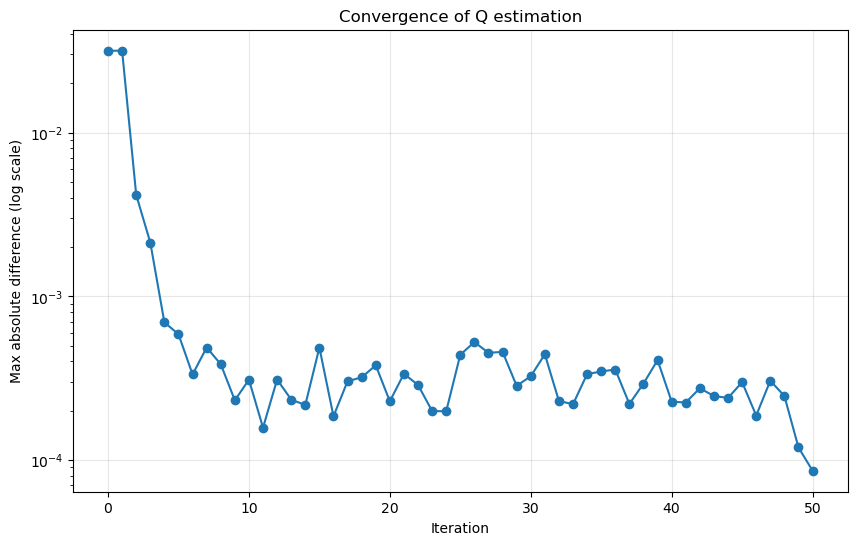

In [48]:
print("\nEstimated Q:")
print(Q_est)
print("\nTrue Q:")
print(Qtreat)
plt.figure(figsize=(10, 6))
plt.plot(diffs, marker='o')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Max absolute difference (log scale)')
plt.title('Convergence of Q estimation')
plt.grid(True, alpha=0.3)
plt.show()